# this notebook explore the comparisons between converters and non_converters

In [2]:
# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('tidyverse')
quiet_library('lubridate')
quiet_library('janitor')
quiet_library('ggplot2')
quiet_library('ggpubr')
quiet_library('knitr')
quiet_library('plotly')
quiet_library('lme4')
quiet_library('Matrix')
quiet_library("DESeq2")
quiet_library('SingleCellExperiment')
quiet_library('data.table')

Warning message:
“Failed to locate timezone database”


In [3]:
source('/home/workspace/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r')

## take a look of the current metadata
- In the aim1 comparison, how long has the non_converters to current?
- in all current avaiable data, what is the largest time span for non_converters?

In [4]:
# define path 
meta_path = '/home/workspace/github/ra-longitudinal/metadata'
fig_path = '/home/workspace/data/ra_longitudinal/revision_work/figures'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision'
proj_name = 'ALTRA_revision_'

In [5]:
# load aim1 metadata
aim1_meta <- read_csv(file.path(meta_path, 'ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv'),
                     show_col_types = FALSE)
# load overall metadata 
altra_meta <- read_csv(file.path(meta_path, '2023-11-22_ALTRA_Metadata_labs.csv'),
                     show_col_types = FALSE)

New names:
• `record_id...112` -> `record_id...128`
• `record_id...120` -> `record_id...136`
• `record_id...114` -> `record_id...140`
• `record_id...123` -> `record_id...141`


In [6]:
aim1_meta <- altra_meta %>% filter(sample.sampleKitGuid %in% aim1_meta$sample.sampleKitGuid)

In [7]:
# remove CU1002 from the comparison
aim1_meta <- aim1_meta %>% filter(subject.subjectGuid!='CU1002')
aim1_meta%>%colnames()

[1] "Status_Xsec"                                                      
  [2] "Status_Long"                                                      
  [3] "sample.sampleKitGuid"                                             
  [4] "sample.visitName"                                                 
  [5] "sample.visitDetails"                                              
  [6] "sample.drawDate"                                                  
  [7] "sample.daysSinceFirstVisit"                                       
  [8] "subject.subjectGuid"                                              
  [9] "subject.biologicalSex"                                            
 [10] "subject.birthYear"                                                
 [11] "subject.ethnicity"                                                
 [12] "subject.race"                                                     
 [13] "cohort.cohortGuid"                                                
 [14] "Age2023"                                                          
 [15] "ageAtDraw"                                                        
 [16] "timeOnStudy"                                                      
 [17] "timeOnStudyAsOf"                                                  
 [18] "percent_basophils"                                                
 [19] "percent_eosinophils"                                              
 [20] "percent_immature_granulocytes"                                    
 [21] "percent_lymphocytes"                                              
 [22] "percent_monocytes"                                                
 [23] "percent_nucleated_red_blood_cells_nrbc"                           
 [24] "0401_count"                                                       
 [25] "0404_count"                                                       
 [26] "0405_count"                                                       
 [27] "0408_count"                                                       
 [28] "absolute_basophil_count"                                          
 [29] "absolute_eosinophil_count_aec"                                    
 [30] "absolute_immature_granulocyte_count"                              
 [31] "absolute_lymphocyte_count_alc"                                    
 [32] "absolute_monocyte_count_amc"                                      
 [33] "absolute_neutrophil_count_anc"                                    
 [34] "alanine_transaminase_alt"                                         
 [35] "albumin"                                                          
 [36] "alkaline_phosphatase"                                             
 [37] "anion_gap"                                                        
 [38] "anti_ccp3"                                                        
 [39] "anti_ccp31"                                                       
 [40] "bilirubin_total_t_bili"                                           
 [41] "c_reactive_protein_crp"                                           
 [42] "calcium"                                                          
 [43] "carbon_dioxide_co2"                                               
 [44] "cholesterol_hdl"                                                  
 [45] "cholesterol_ldl"                                                  
 [46] "cholesterol_total"                                                
 [47] "converted_to_ia_during_course_of_study"                           
 [48] "converted_to_ra_during_study"                                     
 [49] "covid_19_vaccine_company_name"                                    
 [50] "covid_19_vaccine_ever_received"                                   
 [51] "creatinine"                                                       
 [52] "estimated_glomerular_filtration_rate_egfr_non_african_american"   
 [53] "glucose"                                                          
 [54] "has_the_patient_been_fasting?"                                    
 [55] 

In [8]:
# check converters and non_converters 
aim1_meta %>% group_by(Status_Xsec, Status_Long)%>%tally()
# aim1_meta %>% group_by(Status_Xsec)%>%tally()

Status_Xsec,Status_Long,n
<chr>,<chr>,<int>
ALTRA_healthy,NA,31
at_risk,pre,14
at_risk,NA,30


In [9]:
# make a new class for converters, non_converters
aim1_meta <- aim1_meta %>% 
    mutate(status_converter = case_when(Status_Xsec=='at_risk' & Status_Long=='pre' ~ 'converter', 
                                        Status_Xsec=='at_risk' & is.na(Status_Long) ~ 'non_converter',
                                       TRUE ~ 'ALTRA_healthy'),
          day_from_conv_curr = if_else(is.na(days_to_conversion), 
                                       as.numeric(as_date('2024-06-01') - as_date(sample.drawDate)), 
                                     -days_to_conversion), 
          rfigm_result = if_else(rfigm_result==999, NA, rfigm_result))
    

In [10]:
aim1_meta$day_from_conv_curr

[1]  714  632  615 1674 1674 1144 1644 1613 1613 1644 1705 1613 1613 1037 1644
[16] 1705 1582  614 1613 1582 1553 1613 1582 1582 1613 1400  238  204 1674 1431
[31] 1431 1369 1339  818  552 1127 1157  717  279  170 1157 1157  264 1004  609
[46]  670  762  639  639  639  823  851  851  851  851  851  913  851  823  851
[61]  851  517  762  762  762  762  548  517  458  517  397  336  458  427  366

In [11]:
aim1_meta %>% group_by(status_converter, subject.biologicalSex)%>%tally()
# aim1_meta %>% get_dupes(subject.subjectGuid)

status_converter,subject.biologicalSex,n
<chr>,<chr>,<int>
ALTRA_healthy,Female,27
ALTRA_healthy,Male,4
converter,Female,12
converter,Male,2
non_converter,Female,23
non_converter,Male,7


Saving 6.67 x 6.67 in image


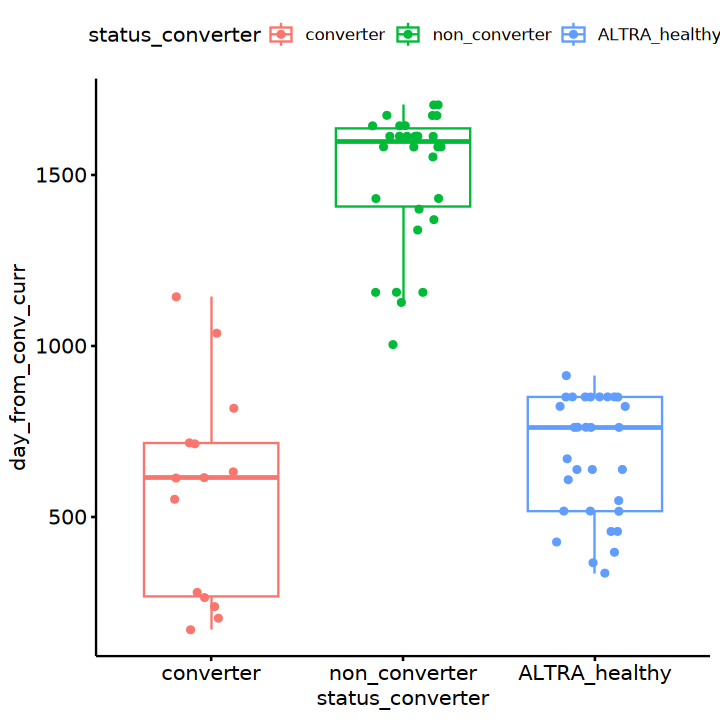

In [12]:
options(repr.plot.width = 6, repr.plot.height = 6)
p1<-aim1_meta%>%ggboxplot(x='status_converter', y='day_from_conv_curr', color='status_converter', add='jitter')
p1
ggsave(file.path(fig_path, 'ALTRA_conv_non_conv_days_from_to_conv.png'))

Warning message:
“Removed 1 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 7 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_point()`).”


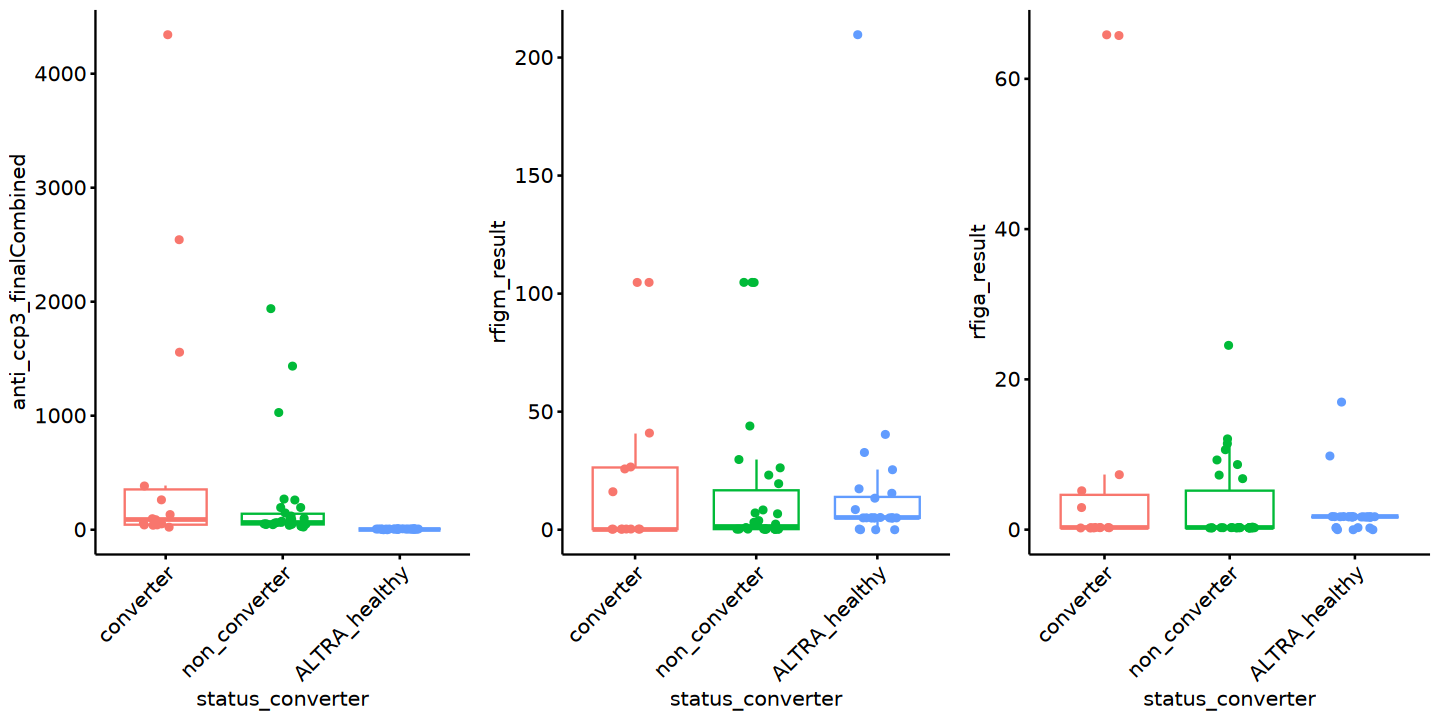

In [19]:
options(repr.plot.width = 12, repr.plot.height = 6)
p1<-aim1_meta%>%ggboxplot(x='status_converter', y='anti_ccp3_finalCombined',  #yscale='log10',
                      color='status_converter', add='jitter')+
  theme(legend.position="none")+ 
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 
p2<-aim1_meta%>%ggboxplot(x='status_converter', y='rfigm_result', #yscale='log10',
                      color='status_converter', add='jitter')+
  theme(legend.position="none")+ 
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 
p3<-aim1_meta%>%ggboxplot(x='status_converter', y='rfiga_result', #yscale='log10',
                      color='status_converter', add='jitter')+
  theme(legend.position="none")+ 
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 
cowplot::plot_grid(p1, p2, p3, nrow = 1)
ggsave(file.path(fig_path, 'ALTRA_conv_non_conv_autoabs.png'), width = 12, height = 6)

In [13]:
aim1_meta%>%filter(status_converter!='ALTRA_healthy') %>%
    rstatix::wilcox_test(anti_ccp3_finalCombined~status_converter)
aim1_meta%>%filter(status_converter!='ALTRA_healthy') %>%
    rstatix::wilcox_test(rfigm_result~status_converter)
aim1_meta%>%filter(status_converter!='ALTRA_healthy') %>%
    rstatix::wilcox_test(rfiga_result~status_converter)

,.y.,group1,group2,n1,n2,statistic,p
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,anti_ccp3_finalCombined,converter,non_converter,14,30,241.5,0.435


,.y.,group1,group2,n1,n2,statistic,p
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,rfigm_result,converter,non_converter,14,30,210,1


,.y.,group1,group2,n1,n2,statistic,p
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,rfiga_result,converter,non_converter,14,30,222.5,0.715


In [14]:
aim1_meta%>%filter(status_converter!='ALTRA_healthy') %>% mutate(log10_ccp3 = log10(anti_ccp3_finalCombined))%>%
    rstatix::wilcox_test(platelet_count~status_converter)

,.y.,group1,group2,n1,n2,statistic,p
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,platelet_count,converter,non_converter,12,29,184,0.785


# Compare the non_converters with converters in original AIM1 (first timepoint)

### quick check on clinical lab

In [15]:
# select clinical lab to test
# select lab to test
lab_to_test = c('absolute_basophil_count','absolute_eosinophil_count_aec',
                'absolute_immature_granulocyte_count','absolute_lymphocyte_count_alc',
                'absolute_monocyte_count_amc','absolute_neutrophil_count_anc','alanine_transaminase_alt',
                'albumin','alkaline_phosphatase','anion_gap','bilirubin_total_t_bili',
                'c_reactive_protein_crp','calcium','carbon_dioxide_co2','cholesterol_hdl',
                'cholesterol_ldl','cholesterol_total','creatinine','glucose','mean_corpuscular_hemoglobin_mch',
                'mean_corpuscular_hemoglobin_concentration_mchc','mean_corpuscular_volume_mcv','nucleated_red_blood_cell_nrbc_count',
                'platelet_count','protein_total','rfiga_result','rfigm_result','red_blood_cell_count','se_count',
                'sed_rate_westergren_esr','sodium','triglycerides','white_blood_cell_count_wbc','rheumatoid_factor_iga',
                'anti_ccp3_finalCombined')
aim1_lab <- aim1_meta %>% 
    select(all_of(c(lab_to_test, 
                     'Status_Xsec', 'ageAtDraw', 'shared_epitope',
                    'subject.biologicalSex', 'sample.sampleKitGuid', 'status_converter')))

# run test in all labs
aim1_lab_long <- aim1_lab %>% pivot_longer(cols = all_of(lab_to_test), names_to = 'lab', values_to = 'value')

In [16]:
 # run wilcox test for frequency pretreatment vs healthy 
aim1_lab_stats_wilcox <- aim1_lab_long %>% 
    filter(status_converter%in%c('non_converter', 'converter'))%>% 
    mutate(status_converter=factor(status_converter, levels = c('non_converter', 'converter'))) %>%
    group_by(lab) %>% 
    rstatix::wilcox_test(data =., value ~ status_converter) %>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
aim1_lab_stats_wilcox %>% filter(p<0.05) %>% arrange(p)

lab,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
carbon_dioxide_co2,value,non_converter,converter,29,13,290,0.00531,0.18585,ns
mean_corpuscular_volume_mcv,value,non_converter,converter,29,12,248,0.03520,0.61600,ns


### rerun degs for HC vs conv, non-conv

In [17]:
# download the pseudobulk 
hise::cacheFiles(fileIds = list('65d0870f-8ebc-4682-b1d0-e2cf21997fde', 
                                '6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1', 
                                'e998f299-a8d0-4137-9cfc-084d6b663ba0'))

[1] "downloading fileID 65d0870f-8ebc-4682-b1d0-e2cf21997fde"
[1] "downloading fileID 6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1"
[1] "downloading fileID e998f299-a8d0-4137-9cfc-084d6b663ba0"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/65d0870f-8ebc-4682-b1d0-e2cf21997fde/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM1_psedobulk_object_list.rds"
[2] "/home/workspace/input/569004694/UCSDCU_Y4/6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM3_psedobulk_object_list.rds"
[3] "/home/workspace/input/569004694/UCSDCU_Y4/e998f299-a8d0-4137-9cfc-084d6b663ba0/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM2_psedobulk_object_list.rds"

In [18]:
# load AIM1 psedobulk object
aim1_pb <- readRDS(
    '/home/workspace/input/569004694/UCSDCU_Y4/65d0870f-8ebc-4682-b1d0-e2cf21997fde/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM1_psedobulk_object_list.rds')

In [19]:
names(aim1_pb)%>%length()

[1] 84

In [20]:
# check the samples numbers
count_status <- function(x, celltype_col = 'AIFI_L3_new', group_col = 'Status_Xsec') {
    sample_counts = colData(x)%>%as_tibble()%>%
        group_by(.data[[group_col]])%>%summarise(sample_number = n(),
                                         cell_type = unique(.data[[celltype_col]]))
    return(sample_counts)
}

# Applying the function to each SCE object in the list
status_counts <- lapply(aim1_pb, count_status)%>%data.table::rbindlist()%>%
    pivot_wider(id_cols = 'cell_type', names_from = 'Status_Xsec',
                values_from = 'sample_number', values_fill = 0)


In [21]:
# selecting celltypes that has atleast 5 at-risk samples and 5 HC samples
status_counts_fl = status_counts%>%filter(at_risk>=5&ALTRA_healthy>=5)
cell_types_to_keep = status_counts_fl%>%pull(cell_type)
cell_types_to_keep%>%length()

[1] 67

In [22]:
# use the same 67 cells type in the original analysis
subset_aim1_pb <- aim1_pb[names(aim1_pb) %in% cell_types_to_keep]

In [119]:
length(subset_aim1_pb)

[1] 67

In [23]:
## B182 had dominant batch effect and need to adjust
subset_aim1_pb <- lapply(subset_aim1_pb, function(pb){
    # remove CU1002 
    pb = pb[ , colData(pb)$subject.subjectGuid != 'CU1002']
    # add converter/ non-conv status
    colData(pb) = colData(pb)%>% as.data.frame()%>%
        left_join(select(aim1_meta, c('status_converter', 'sample.sampleKitGuid')), 
                                    by='sample.sampleKitGuid') %>% DataFrame()
    pb$batch_corr = ifelse(pb$file.batchID == "B182", "B182", "other_batches")
    # Modify disease category in coldata and convert to factor
    # Assuming 'status' is the column you want to modify
    pb$Status_Xsec <- factor(pb$Status_Xsec, levels = c("ALTRA_healthy", "at_risk"))
    pb$status_converter <- factor(pb$status_converter, levels = c("ALTRA_healthy", "non_converter", "converter"))
    pb$batch_corr <- factor(pb$batch_corr, levels = c("other_batches", "B182"))
    pb$subject.biologicalSex <- factor(pb$subject.biologicalSex, levels = c("Female", "Male"))
    pb$age <- lubridate::year(lubridate::as_date(pb$sample.drawDate)) - as.numeric(pb$subject.birthYear)
    pb$scale_age = scale(pb$age)
    pb$scale_bmi = scale(pb$BMI)
    return(pb)
})

In [24]:
# run deseq to do deg analysis
formula = '~ scale_age + scale_bmi + subject.biologicalSex + batch_corr + status_converter'
aim1_deseq <- RunDeseq_list(subset_aim1_pb, formula)

run Deseq2 for cell type Adaptive NK cell

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type Adaptive NK cell_uk1_T

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type C1Q+ CD16 monocyte

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type CD14+ cDC2

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell ty

In [25]:
# add deseq noamrlized count to the se objects
aim1_pb_norm <- addNormcountsList(subset_aim1_pb, aim1_deseq, method = "vst",
                              assay_name = "normalized_counts")

Add normalized counts for Adaptive NK cell

Add normalized counts for Adaptive NK cell_uk1_T

Add normalized counts for C1Q+ CD16 monocyte

Add normalized counts for CD14+ cDC2

Add normalized counts for CD27- effector B cell

Add normalized counts for CD27+ effector B cell

Add normalized counts for CD4 MAIT

Add normalized counts for CD56bright NK cell

Add normalized counts for CD8 MAIT

Add normalized counts for CD8aa

Add normalized counts for CD95 memory B cell

Add normalized counts for cDC1

Add normalized counts for CM CD4 T cell

Add normalized counts for CM CD4 T cell_uk1_CD8

Add normalized counts for CM CD4 T cell_uk2

Add normalized counts for CM CD8 T cell

Add normalized counts for CMP cell

Add normalized counts for Core CD14 monocyte

Add normalized counts for Core CD16 monocyte

Add normalized counts for Core memory B cell

Add normalized counts for Core naive B cell

Add normalized counts for Core naive CD4 T cell

Add normalized counts for Core naive CD8 T cell

Ad

In [26]:
aim1_pb_norm %>% saveRDS(file.path(output_path, paste0(proj_name, 'AIM1_conv_nonconv_norm_counts_object.rds')))

In [27]:
aim1_deseq %>% saveRDS(file.path(output_path, paste0(proj_name, 'AIM1_conv_nonconv_deseq2_object.rds')))

In [29]:
# get deseq2 result
aim1deseq_res <- lapply(aim1_deseq, function(dds){
    celltype = dds$AIFI_L3_new%>%unique()
    res_nonconv_conv = results(dds, contrast=c("status_converter",  "converter", "non_converter")) %>% 
        as_tibble(rownames = 'gene') %>% mutate('contrast' = 'nonconv_vs_conv')
    res_hc_conv = results(dds, contrast=c("status_converter", "converter", "ALTRA_healthy")) %>% 
        as_tibble(rownames = 'gene') %>% mutate('contrast' = 'hc_vs_conv')
    res_hc_nonconv = results(dds, contrast=c("status_converter", "non_converter", "ALTRA_healthy")) %>% 
        as_tibble(rownames = 'gene') %>% mutate('contrast' = 'hc_vs_nonconv')
    res = res_nonconv_conv %>% bind_rows(res_hc_conv) %>% bind_rows(res_hc_nonconv)%>%
        mutate(cell_type = celltype) 
    return(res)
})%>%rbindlist()

In [98]:
# calculate the qvalues
# library(qvalue)
calQvalue <- function(x, p_col = 'p.value'){
    # test
    pvalues <- x %>% pull(.data[[p_col]])
    qvalues <- qvalue::qvalue(pvalues)$qvalues
    x <- x %>% mutate('qvalue'=qvalues)
    return(x)
}
aim1deseq_res_tb <- aim1deseq_res %>%
    group_by(cell_type, contrast) %>% 
    group_modify(~calQvalue(.x, p_col = 'pvalue'))%>%
    rstatix::add_significance(p.col = 'qvalue', output.col = 'sig',
                              cutpoints = c(0, 0.05, 0.2, 1),
                              symbols = c( "*", "<0.2", "ns"))%>%ungroup()

In [99]:
aim1deseq_res_tb%>%fwrite(file.path(output_path, paste0(proj_name, 'AIM1_conv_nonconv_deseq2_deg.tsv')))

In [100]:
aim1deseq_res_tb%>%head()

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Adaptive NK cell,hc_vs_conv,AAK1,45.28766,0.22030951,0.1548591,1.4226452,0.15483905,0.8563228,0.7853809,ns
Adaptive NK cell,hc_vs_conv,ABCF1,25.71824,-0.03022246,0.1436013,-0.2104609,0.83330794,0.9758408,0.8949973,ns
Adaptive NK cell,hc_vs_conv,ABHD17A,104.92994,0.02596325,0.0809878,0.3205822,0.74852702,0.9634802,0.8836608,ns
Adaptive NK cell,hc_vs_conv,ABI1,18.00802,-0.12887600,0.1531834,-0.8413186,0.40016949,0.9231247,0.8466485,ns
Adaptive NK cell,hc_vs_conv,ABI3,25.47130,0.29670323,0.1640158,1.8089914,0.07045234,0.7836379,0.7187175,ns
Adaptive NK cell,hc_vs_conv,ABRACL,28.07650,-0.04082090,0.1430682,-0.2853248,0.77539531,0.9637021,0.8838643,ns


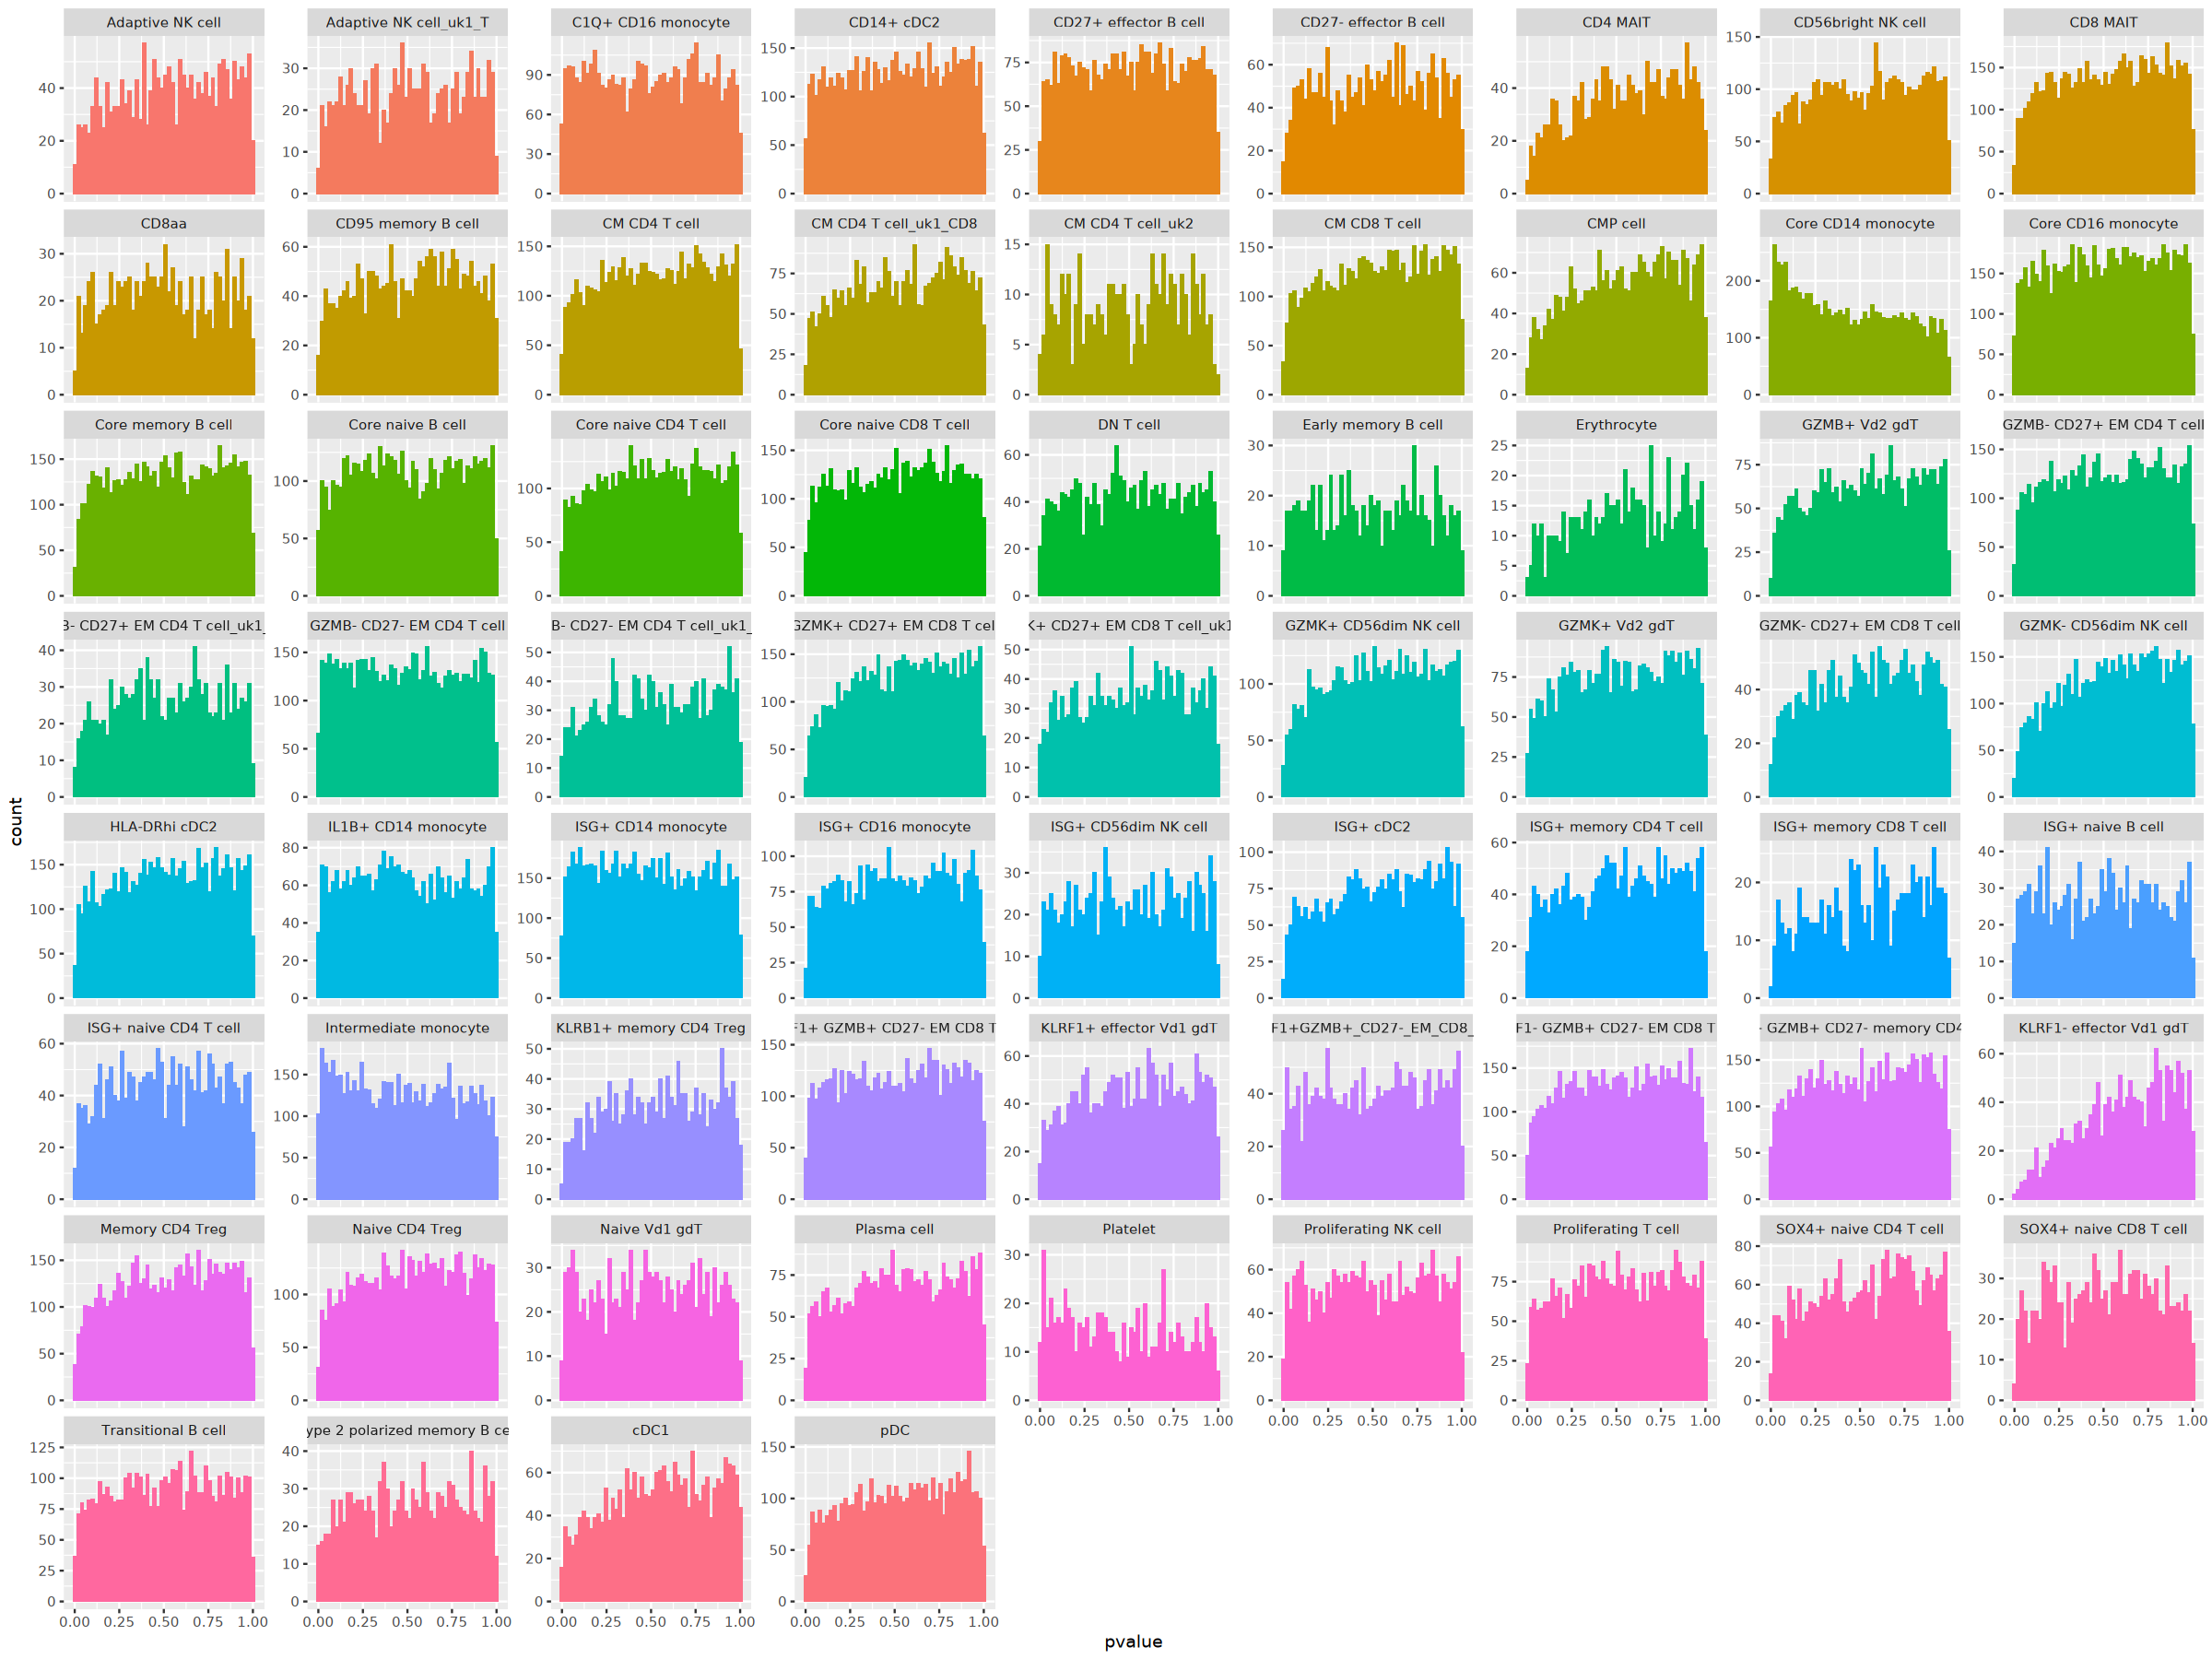

In [33]:
options(repr.plot.width = 20, repr.plot.height = 15)
aim1deseq_res %>% filter(contrast=='nonconv_vs_conv') %>% ggplot(aes(x=pvalue, fill=cell_type)) +
    geom_histogram(bins = 50) +
    facet_wrap(vars(cell_type), scales = 'free_y') +
    theme(legend.position = "none")

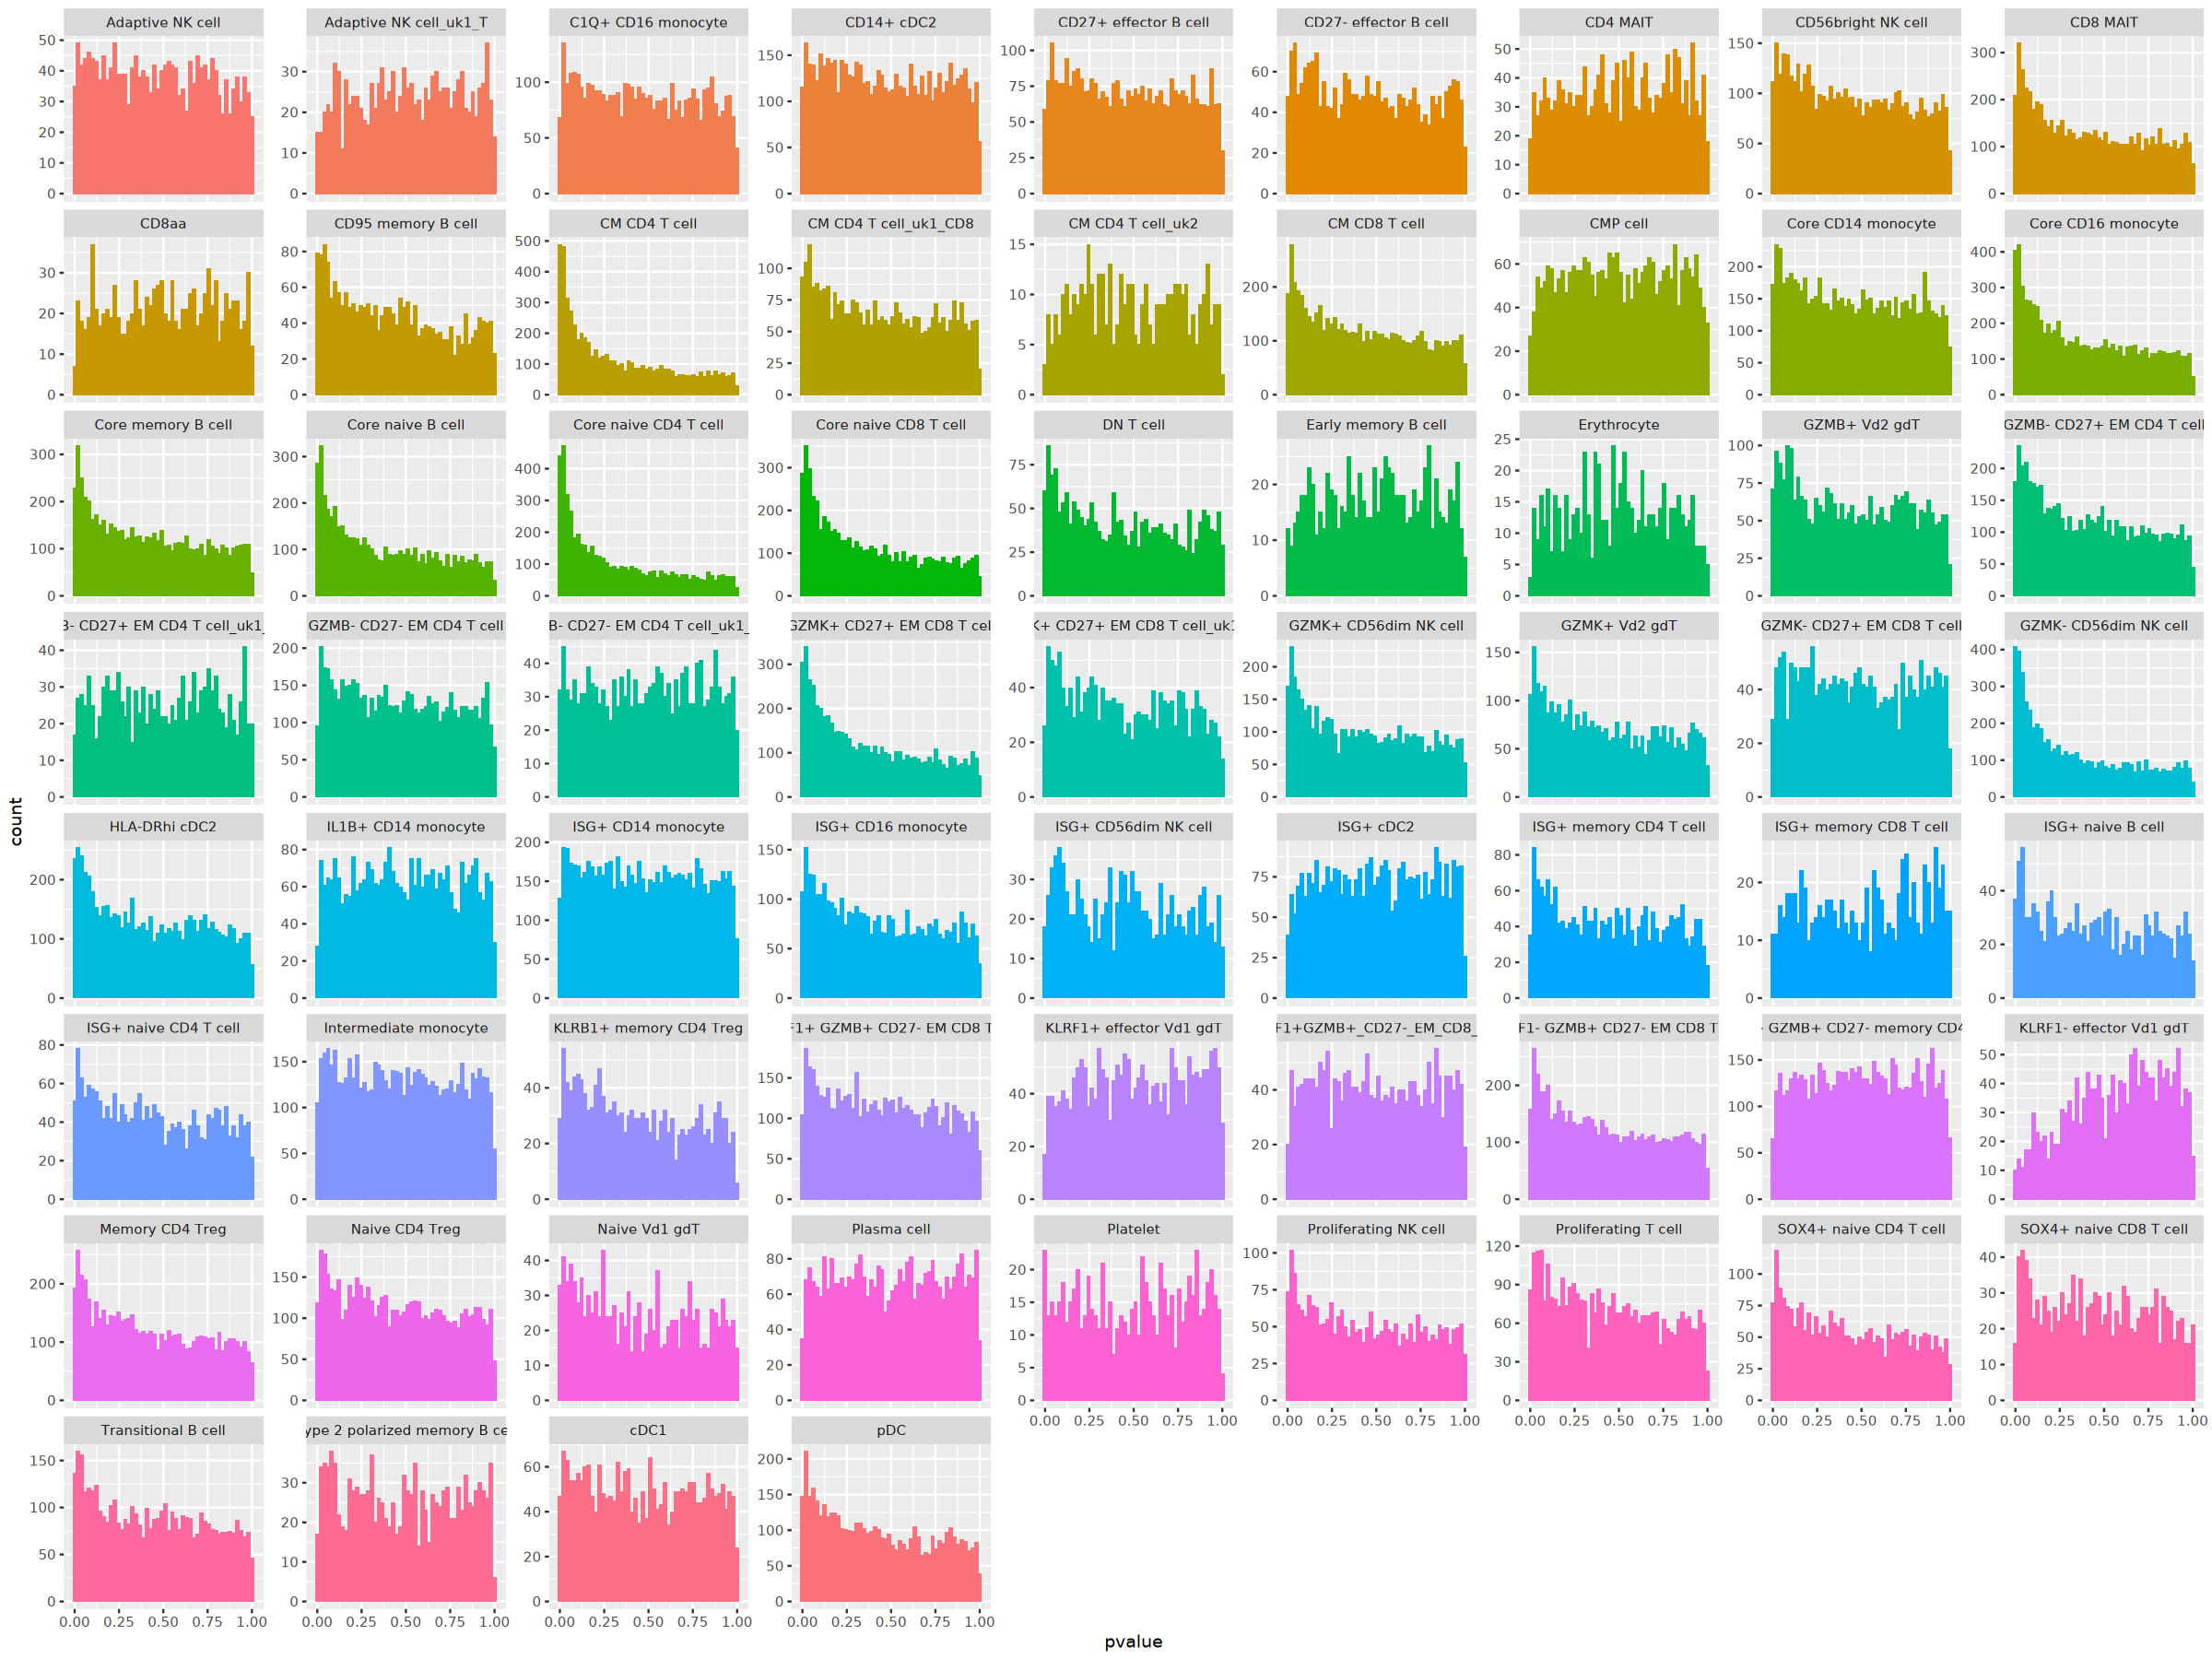

In [34]:
options(repr.plot.width = 20, repr.plot.height = 15)
aim1deseq_res %>% filter(contrast=='hc_vs_conv') %>% ggplot(aes(x=pvalue, fill=cell_type)) +
    geom_histogram(bins = 50) +
    facet_wrap(vars(cell_type), scales = 'free_y') +
    theme(legend.position = "none")

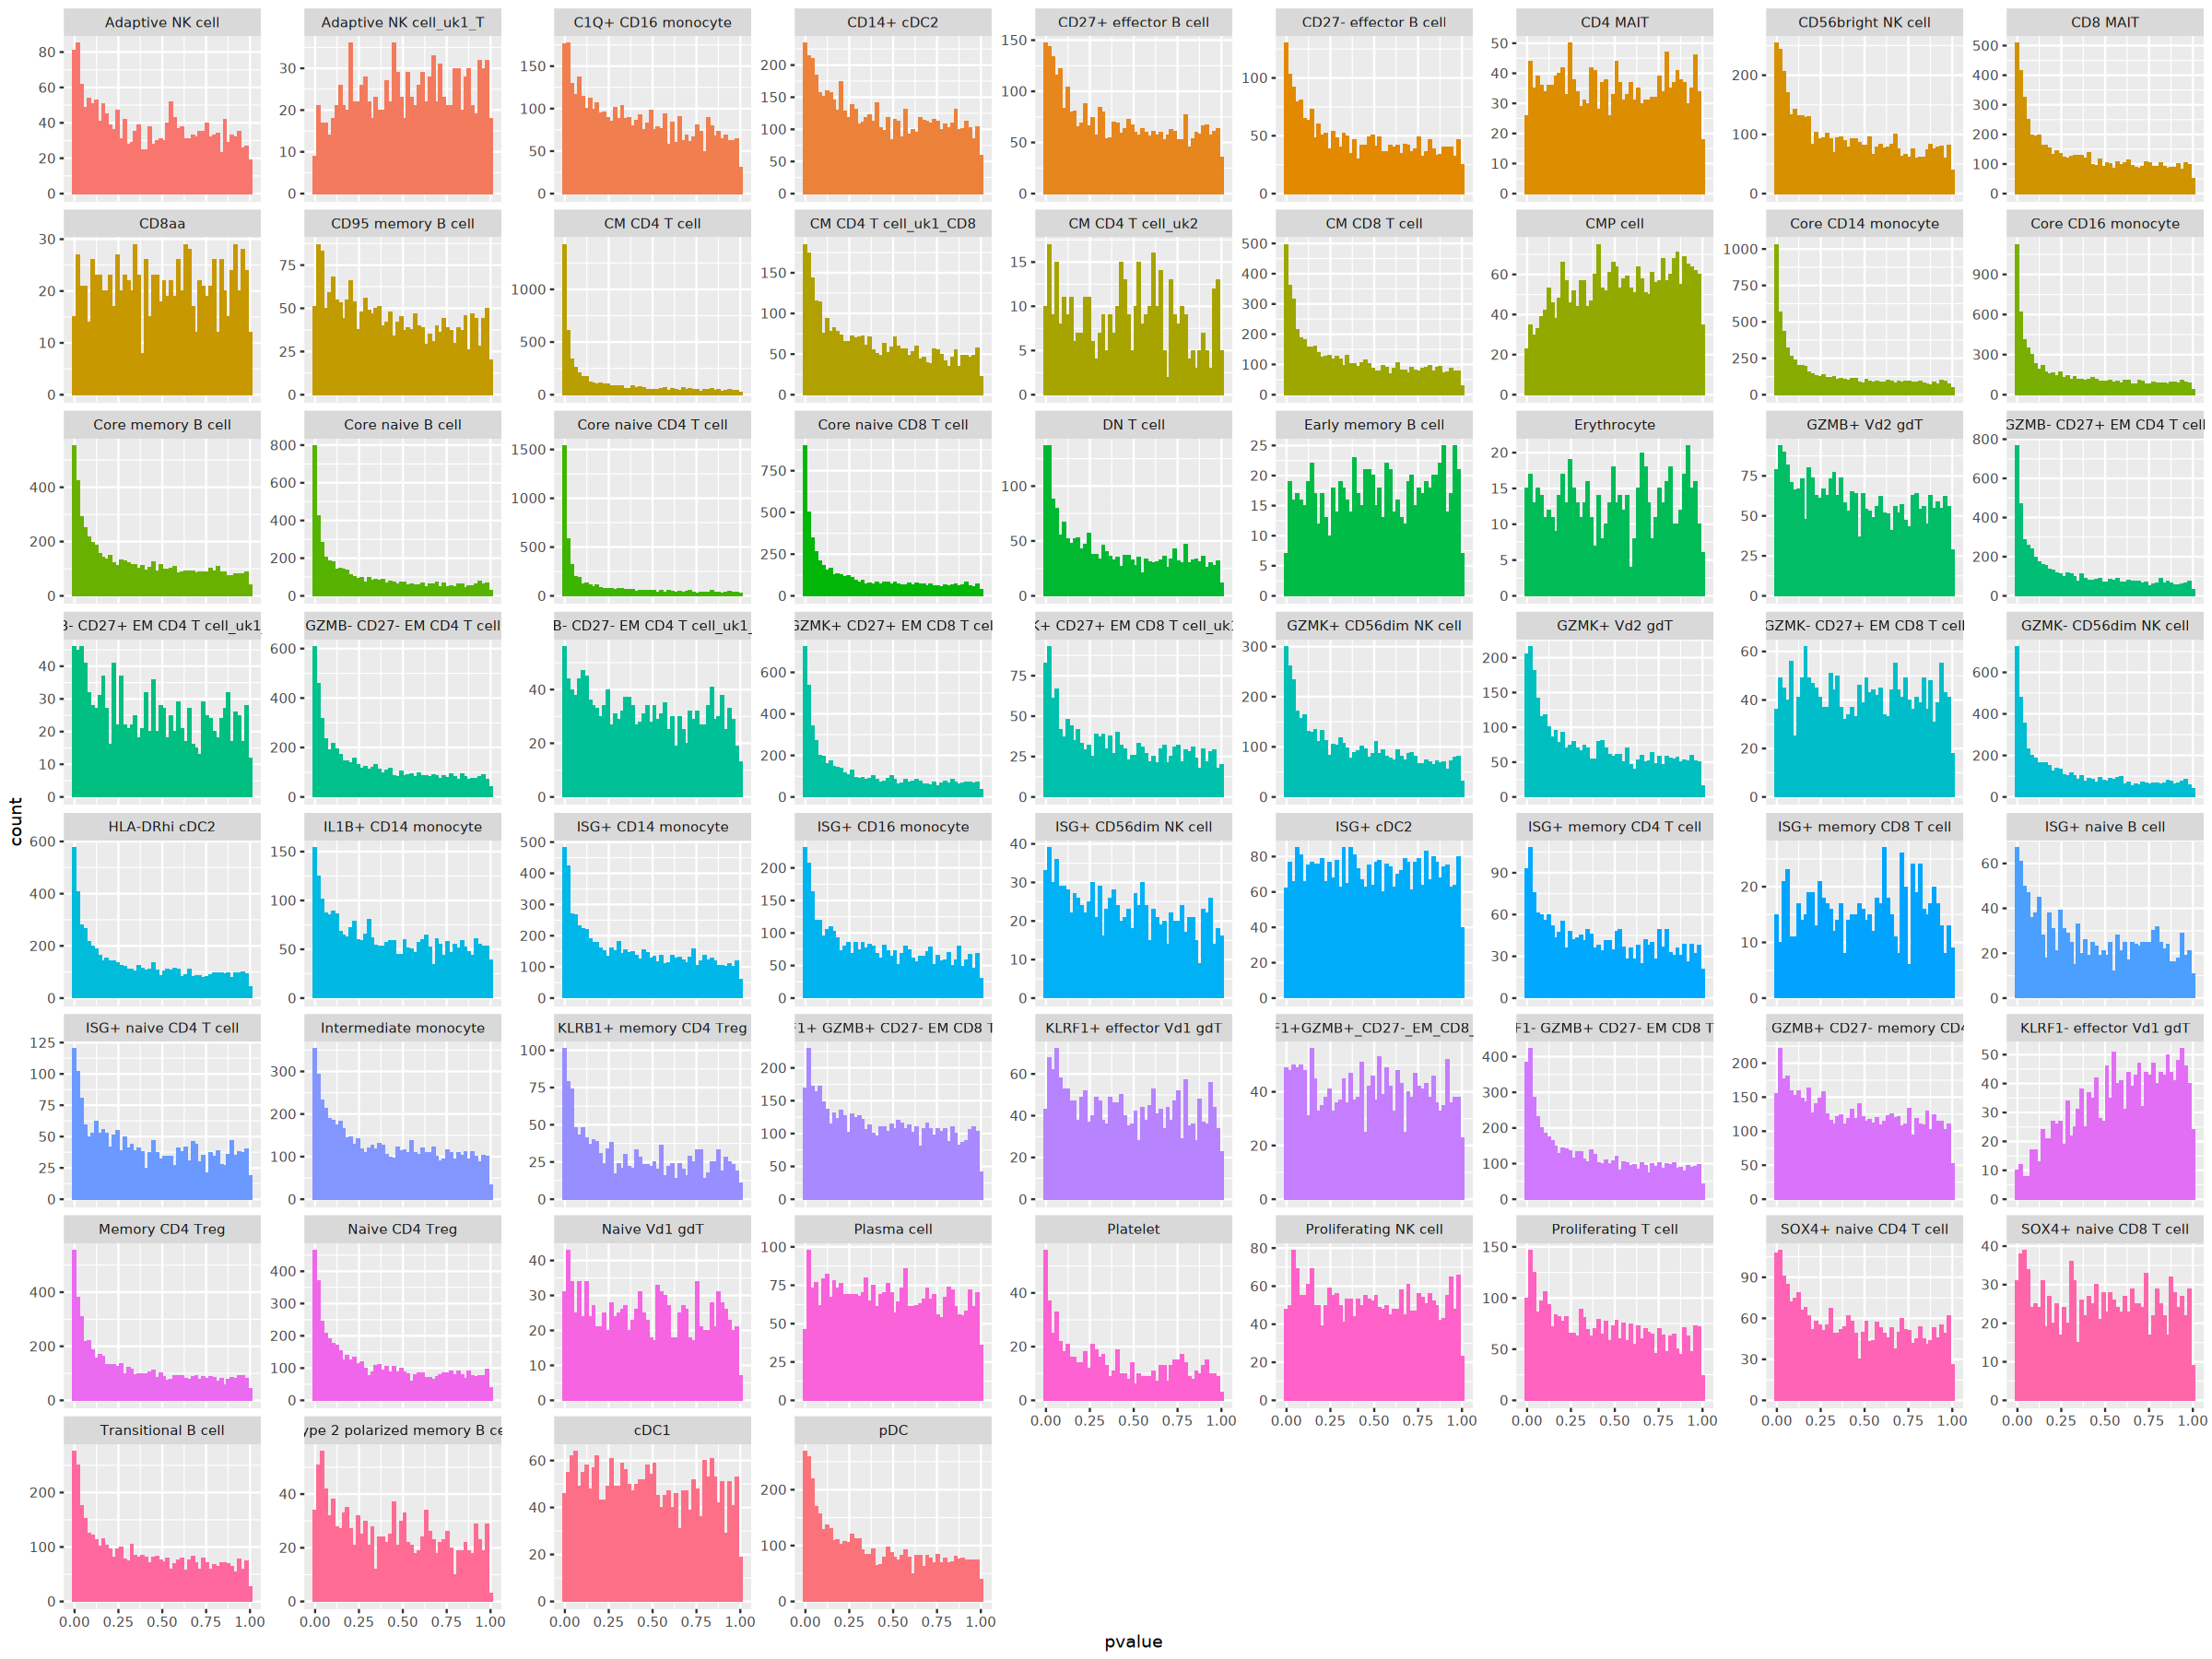

In [35]:
options(repr.plot.width = 20, repr.plot.height = 15)
aim1deseq_res %>% filter(contrast=='hc_vs_nonconv') %>% ggplot(aes(x=pvalue, fill=cell_type)) +
    geom_histogram(bins = 50) +
    facet_wrap(vars(cell_type), scales = 'free_y') +
    theme(legend.position = "none")

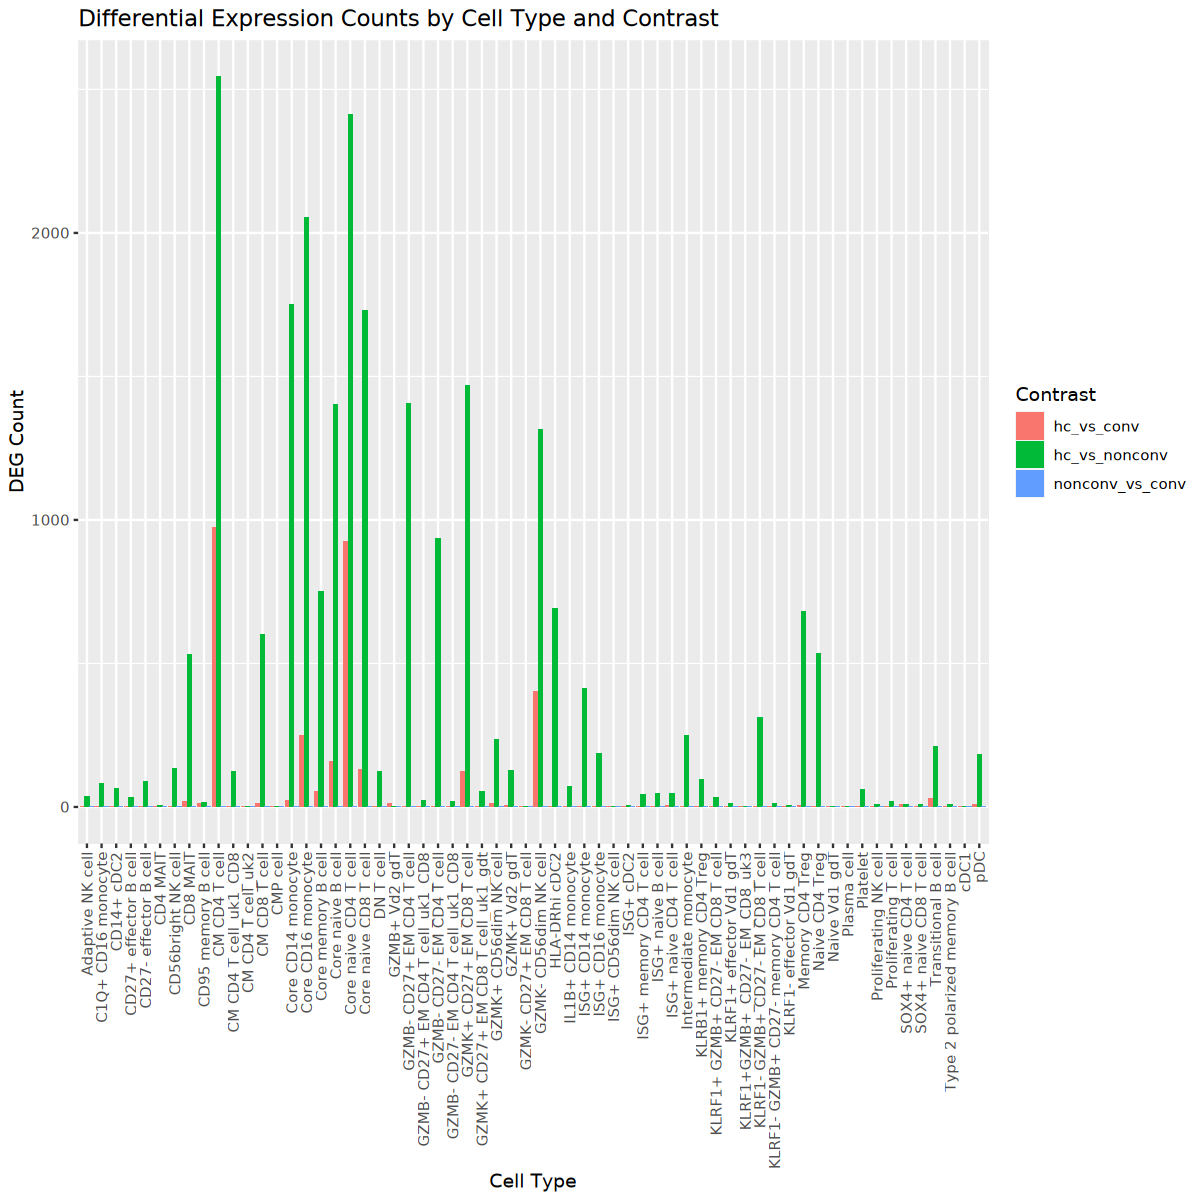

In [101]:
# Count the DEGs and ensure all combinations of cell_type and contrast are included
aim1degs_counts <- aim1deseq_res_tb %>%
  filter(qvalue < 0.1 & abs(log2FoldChange) > 0.1) %>%
  group_by(cell_type, contrast, .drop = FALSE) %>%
  tally() %>%
  ungroup() %>%
  complete(cell_type, contrast, fill = list(n = 0))

# Plot the DEG counts
ggplot(aim1degs_counts, aes(x = cell_type, y = n, fill = contrast)) + 
  geom_bar(position = "dodge", stat = "identity") + 
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)) +
  labs(x = "Cell Type", y = "DEG Count", fill = "Contrast") +
  ggtitle("Differential Expression Counts by Cell Type and Contrast")
ggsave(file.path(fig_path, paste0(proj_name, 'deg_counts.png')), width = 12, height = 6)

In [102]:
aim1deseq_res_tb %>%filter(qvalue<0.2&contrast=='nonconv_vs_conv')

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD8 MAIT,nonconv_vs_conv,CFH,25.03939,0.6628702,0.15786932,4.198854,2.682691e-05,0.1820206,0.18202057,<0.2
Core CD14 monocyte,nonconv_vs_conv,PCSK7,507.67124,0.2268805,0.05818125,3.899546,9.637323e-05,0.2414149,0.19297064,<0.2
Core CD14 monocyte,nonconv_vs_conv,SAMD4B,218.47210,0.2285571,0.05667126,4.033034,5.506134e-05,0.2068930,0.16537615,<0.2
Core CD14 monocyte,nonconv_vs_conv,TMEM87A,418.70589,0.1339698,0.03171881,4.223670,2.403556e-05,0.1806272,0.14438110,<0.2
ISG+ CD56dim NK cell,nonconv_vs_conv,KLRB1,80.92177,0.4180176,0.10943414,3.819810,1.335543e-04,0.1541217,0.15412172,<0.2
Plasma cell,nonconv_vs_conv,EAF2,141.33166,-0.6685405,0.17283746,-3.868030,1.097181e-04,0.1856430,0.18564296,<0.2
Plasma cell,nonconv_vs_conv,IGKV1-39,22.07513,-5.2153755,1.29112903,-4.039391,5.359008e-05,0.1813488,0.18134883,<0.2
Platelet,nonconv_vs_conv,NCOA4,207.69571,-0.6057645,0.14846245,-4.080254,4.498654e-05,0.0330651,0.02975047,*
SOX4+ naive CD8 T cell,nonconv_vs_conv,RPS19,917.65881,0.2139449,0.05513626,3.880294,1.043302e-04,0.1327080,0.12368882,<0.2


In [103]:
# extract normalized gene expression for plotting
conv_nonc_exprs = GetExprsSE(aim1deseq_res_tb %>%filter(qvalue<0.2) %>%
    filter(contrast=='nonconv_vs_conv'), aim1_pb_norm, assay = "normalized_counts")
conv_nonc_exprs%>%head()

index,batch_id,hto_barcode,hto_category,pbmc_sample_id,pool_id,sample.sampleKitGuid,cohort.cohortGuid,subject.subjectGuid,subject.biologicalSex,⋯,psbulk_counts,status_converter,batch_corr,age,scale_age,scale_bmi,cell_type,gene,normalized_counts,celltype_gene
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,⋯,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>
KT00052_CD8 MAIT,B140,ATTGACCCGCGTTAG,singlet,PB00052-02,B140-P2,KT00052,CU1,CU1009,Female,⋯,1861552,converter,other_batches,56,0.01340968,-0.4644263,CD8 MAIT,CFH,5.818345,CD8 MAIT: CFH
KT00056_CD8 MAIT,B002,GGTTGCCAGATGTCA,singlet,PB00056-01,B002-P2,KT00056,CU1,CU1007,Female,⋯,1110807,converter,other_batches,42,-0.85486685,-0.2167752,CD8 MAIT,CFH,5.621305,CD8 MAIT: CFH
KT00057_CD8 MAIT,B002,TGTCTTTCCTGCCAG,singlet,PB00057-01,B002-P2,KT00057,CU1,CU1003,Female,⋯,1182969,converter,other_batches,21,-2.15728164,-1.1416080,CD8 MAIT,CFH,5.861260,CD8 MAIT: CFH
KT00060_CD8 MAIT,B002,CAGTAGTCACGGTCA,singlet,PB00060-01,B002-P2,KT00060,CU1,CU1005,Female,⋯,1278773,non_converter,other_batches,40,-0.97890635,0.9063485,CD8 MAIT,CFH,5.798031,CD8 MAIT: CFH
KT00063_CD8 MAIT,B140,CAGTAGTCACGGTCA,singlet,PB00063-05,B140-P2,KT00063,CU1,CU1011,Male,⋯,1681661,non_converter,other_batches,39,-1.04092611,0.2003882,CD8 MAIT,CFH,5.370422,CD8 MAIT: CFH
KT00064_CD8 MAIT,B140,CTCCTCTGCAATTAC,singlet,PB00064-02,B140-P2,KT00064,CU1,CU1010,Female,⋯,243815,converter,other_batches,58,0.13744918,-0.8267805,CD8 MAIT,CFH,5.911756,CD8 MAIT: CFH


Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


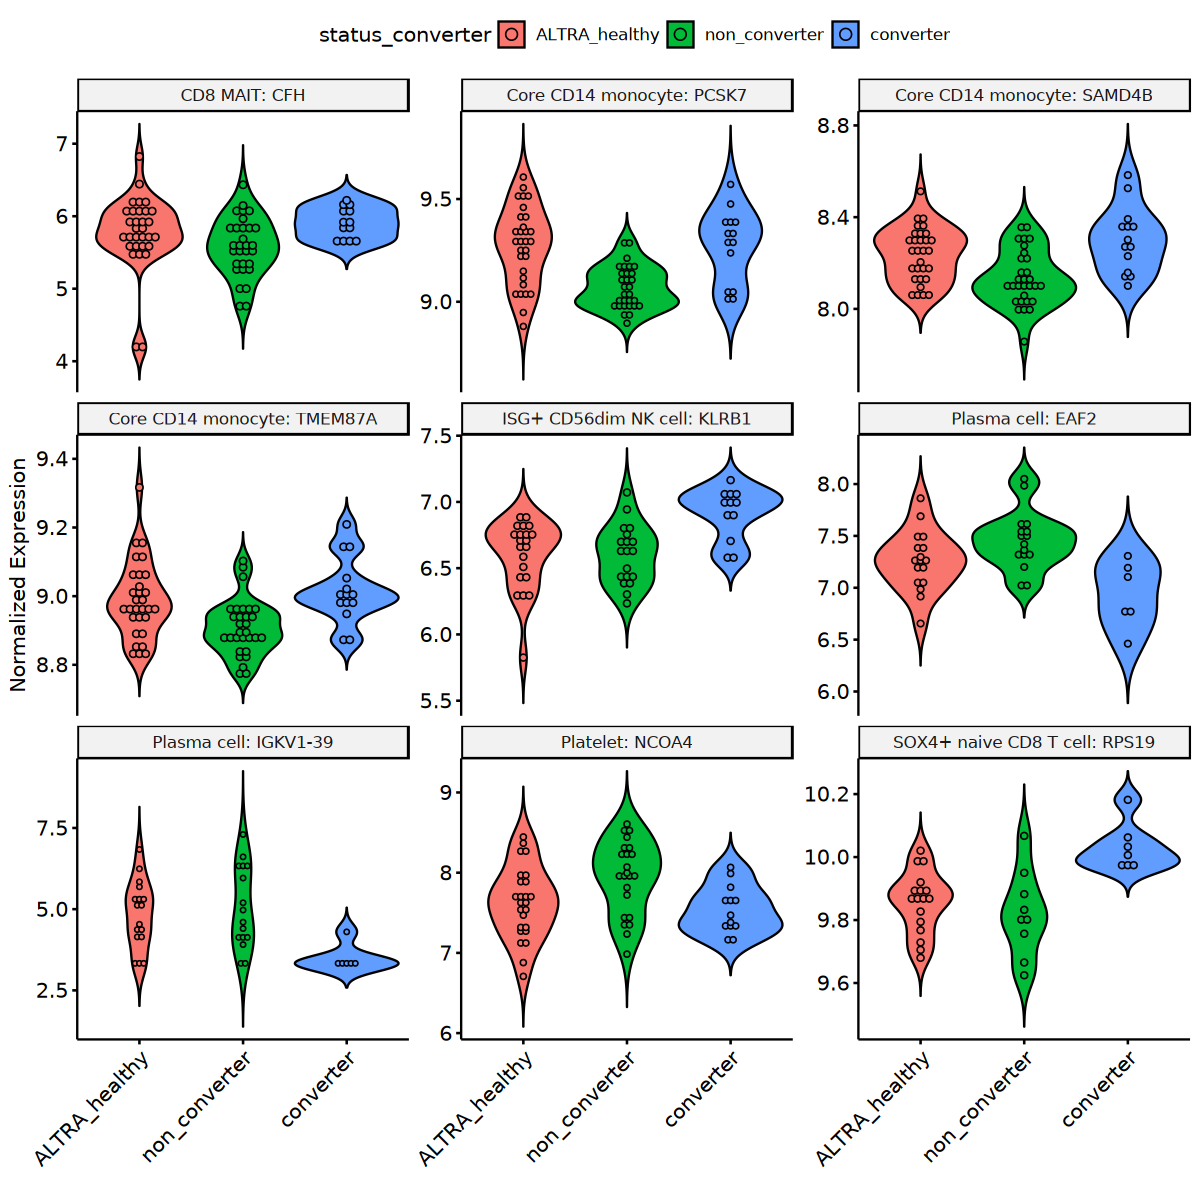

In [104]:
# plot the degs
options(repr.plot.width = 10, repr.plot.height = 10)
conv_nonc_exprs%>%ggpubr::ggviolin(x='status_converter', add = c('dotplot'), 
                            ylab = 'Normalized Expression', xlab = '',
                            y='normalized_counts',# palette = ari_con_colors, 
                            fill='status_converter') + facet_wrap(vars(celltype_gene), scales = 'free_y')+
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave(file.path(fig_path, paste0(proj_name, 'q_0_2_expression_violinplot.png')), width = 12, height = 8)

In [105]:
aim1deseq_res_tb%>%head()
aim1deseq_res_tb%>%distinct(contrast)

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Adaptive NK cell,hc_vs_conv,AAK1,45.28766,0.22030951,0.1548591,1.4226452,0.15483905,0.8563228,0.7853809,ns
Adaptive NK cell,hc_vs_conv,ABCF1,25.71824,-0.03022246,0.1436013,-0.2104609,0.83330794,0.9758408,0.8949973,ns
Adaptive NK cell,hc_vs_conv,ABHD17A,104.92994,0.02596325,0.0809878,0.3205822,0.74852702,0.9634802,0.8836608,ns
Adaptive NK cell,hc_vs_conv,ABI1,18.00802,-0.12887600,0.1531834,-0.8413186,0.40016949,0.9231247,0.8466485,ns
Adaptive NK cell,hc_vs_conv,ABI3,25.47130,0.29670323,0.1640158,1.8089914,0.07045234,0.7836379,0.7187175,ns
Adaptive NK cell,hc_vs_conv,ABRACL,28.07650,-0.04082090,0.1430682,-0.2853248,0.77539531,0.9637021,0.8838643,ns


contrast
<chr>
hc_vs_conv
hc_vs_nonconv
nonconv_vs_conv


In [117]:
# make a comparison table to compare degs between hc vs conv and hc vs non-conv
aim1_conv_nonconv_logfc <- aim1deseq_res_tb%>% filter(contrast%in%c('hc_vs_nonconv', 'hc_vs_conv'))%>%
    pivot_wider(id_cols = c('cell_type', 'gene'), names_from = 'contrast', values_from = 'log2FoldChange')
aim1_conv_nonconv_qvallue <- aim1deseq_res_tb%>% filter(contrast%in%c('hc_vs_nonconv', 'hc_vs_conv'))%>%
    pivot_wider(id_cols = c('cell_type', 'gene'), names_from = 'contrast', values_from = 'qvalue')%>%
    mutate(sigificance = case_when(hc_vs_nonconv<0.1&hc_vs_conv<0.1 ~ 'NonConvSig&ConvSig', 
                    hc_vs_nonconv>0.1&hc_vs_conv<0.1 ~ 'ConvSig', 
                    hc_vs_nonconv<0.1&hc_vs_conv>0.1 ~ 'NonConvSig', 
                    hc_vs_nonconv>0.1&hc_vs_conv>0.1 ~ 'Not sig'))
aim1_conv_nonconv_logfc <- aim1_conv_nonconv_logfc %>% 
    left_join(select(aim1_conv_nonconv_qvallue, c(cell_type, gene, sigificance)), by=c('cell_type', 'gene'))

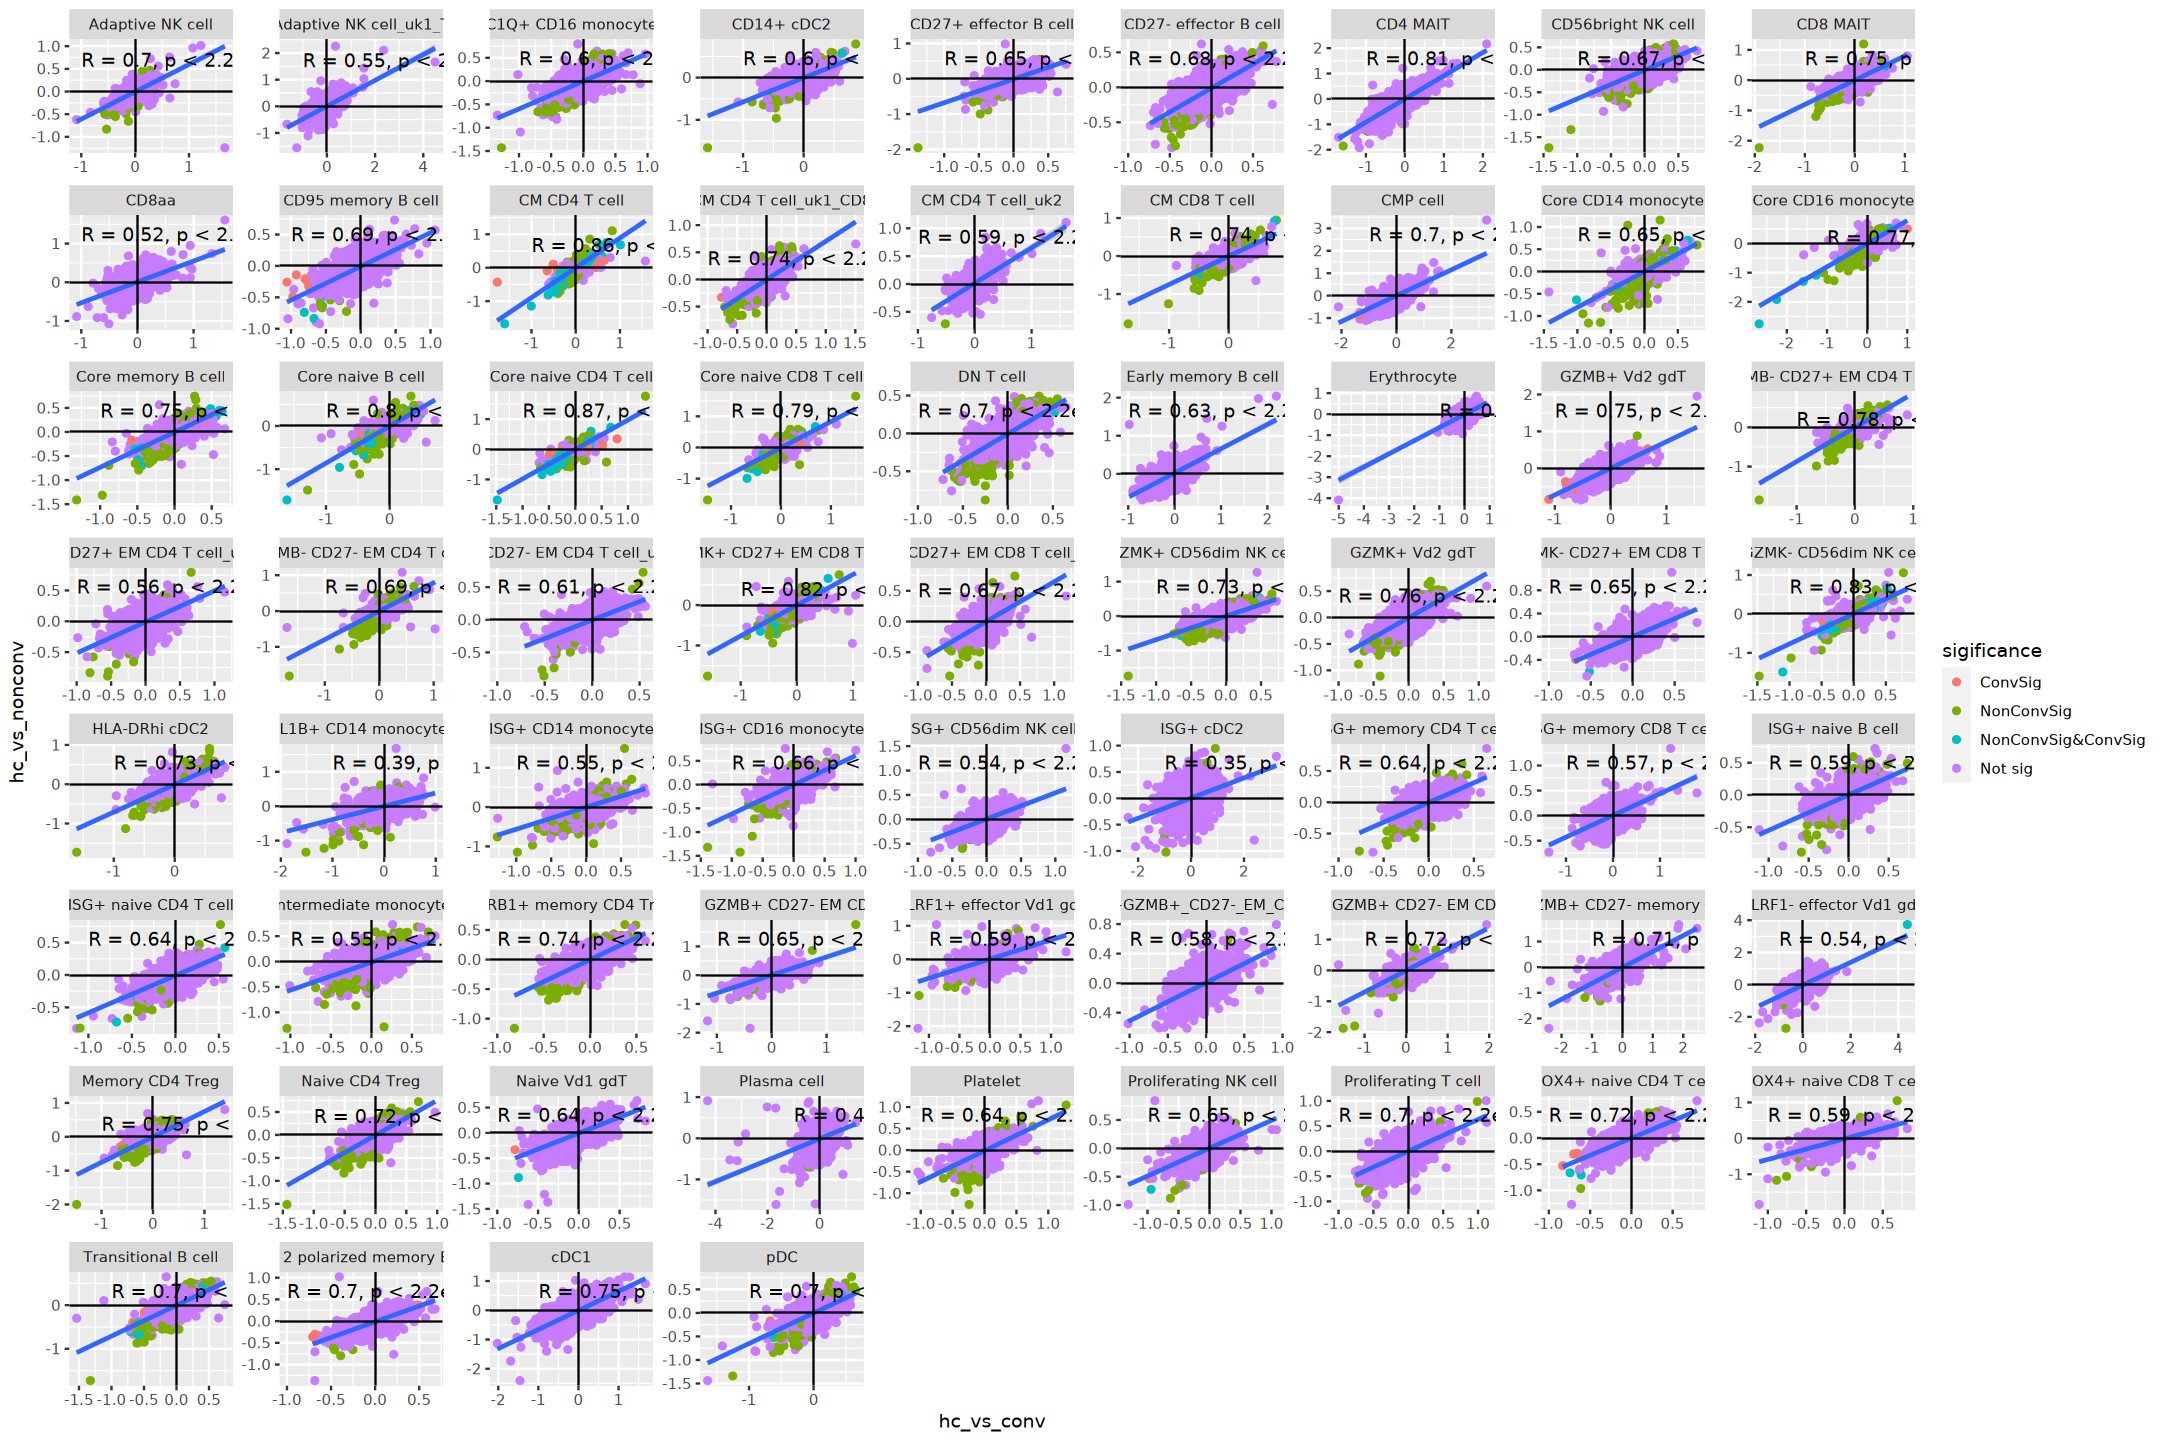

In [121]:
# plot the correlation between the hc vs conv and hc vs non-conv
options(repr.plot.width = 18, repr.plot.height = 12)
p1<- aim1_conv_nonconv_logfc %>%
    ggplot(aes(x=hc_vs_conv, y=hc_vs_nonconv
                          )) +
    geom_point(aes(color=sigificance)) +                                      
  stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+
    facet_wrap(vars(cell_type), scale='free')+ 
    ggpubr::stat_cor(method = "spearman", label.x = -1)
p1
ggsave(file.path(fig_path, paste0(proj_name,'deg_logfc_cor_plot.png')),
       width=24, height=18)

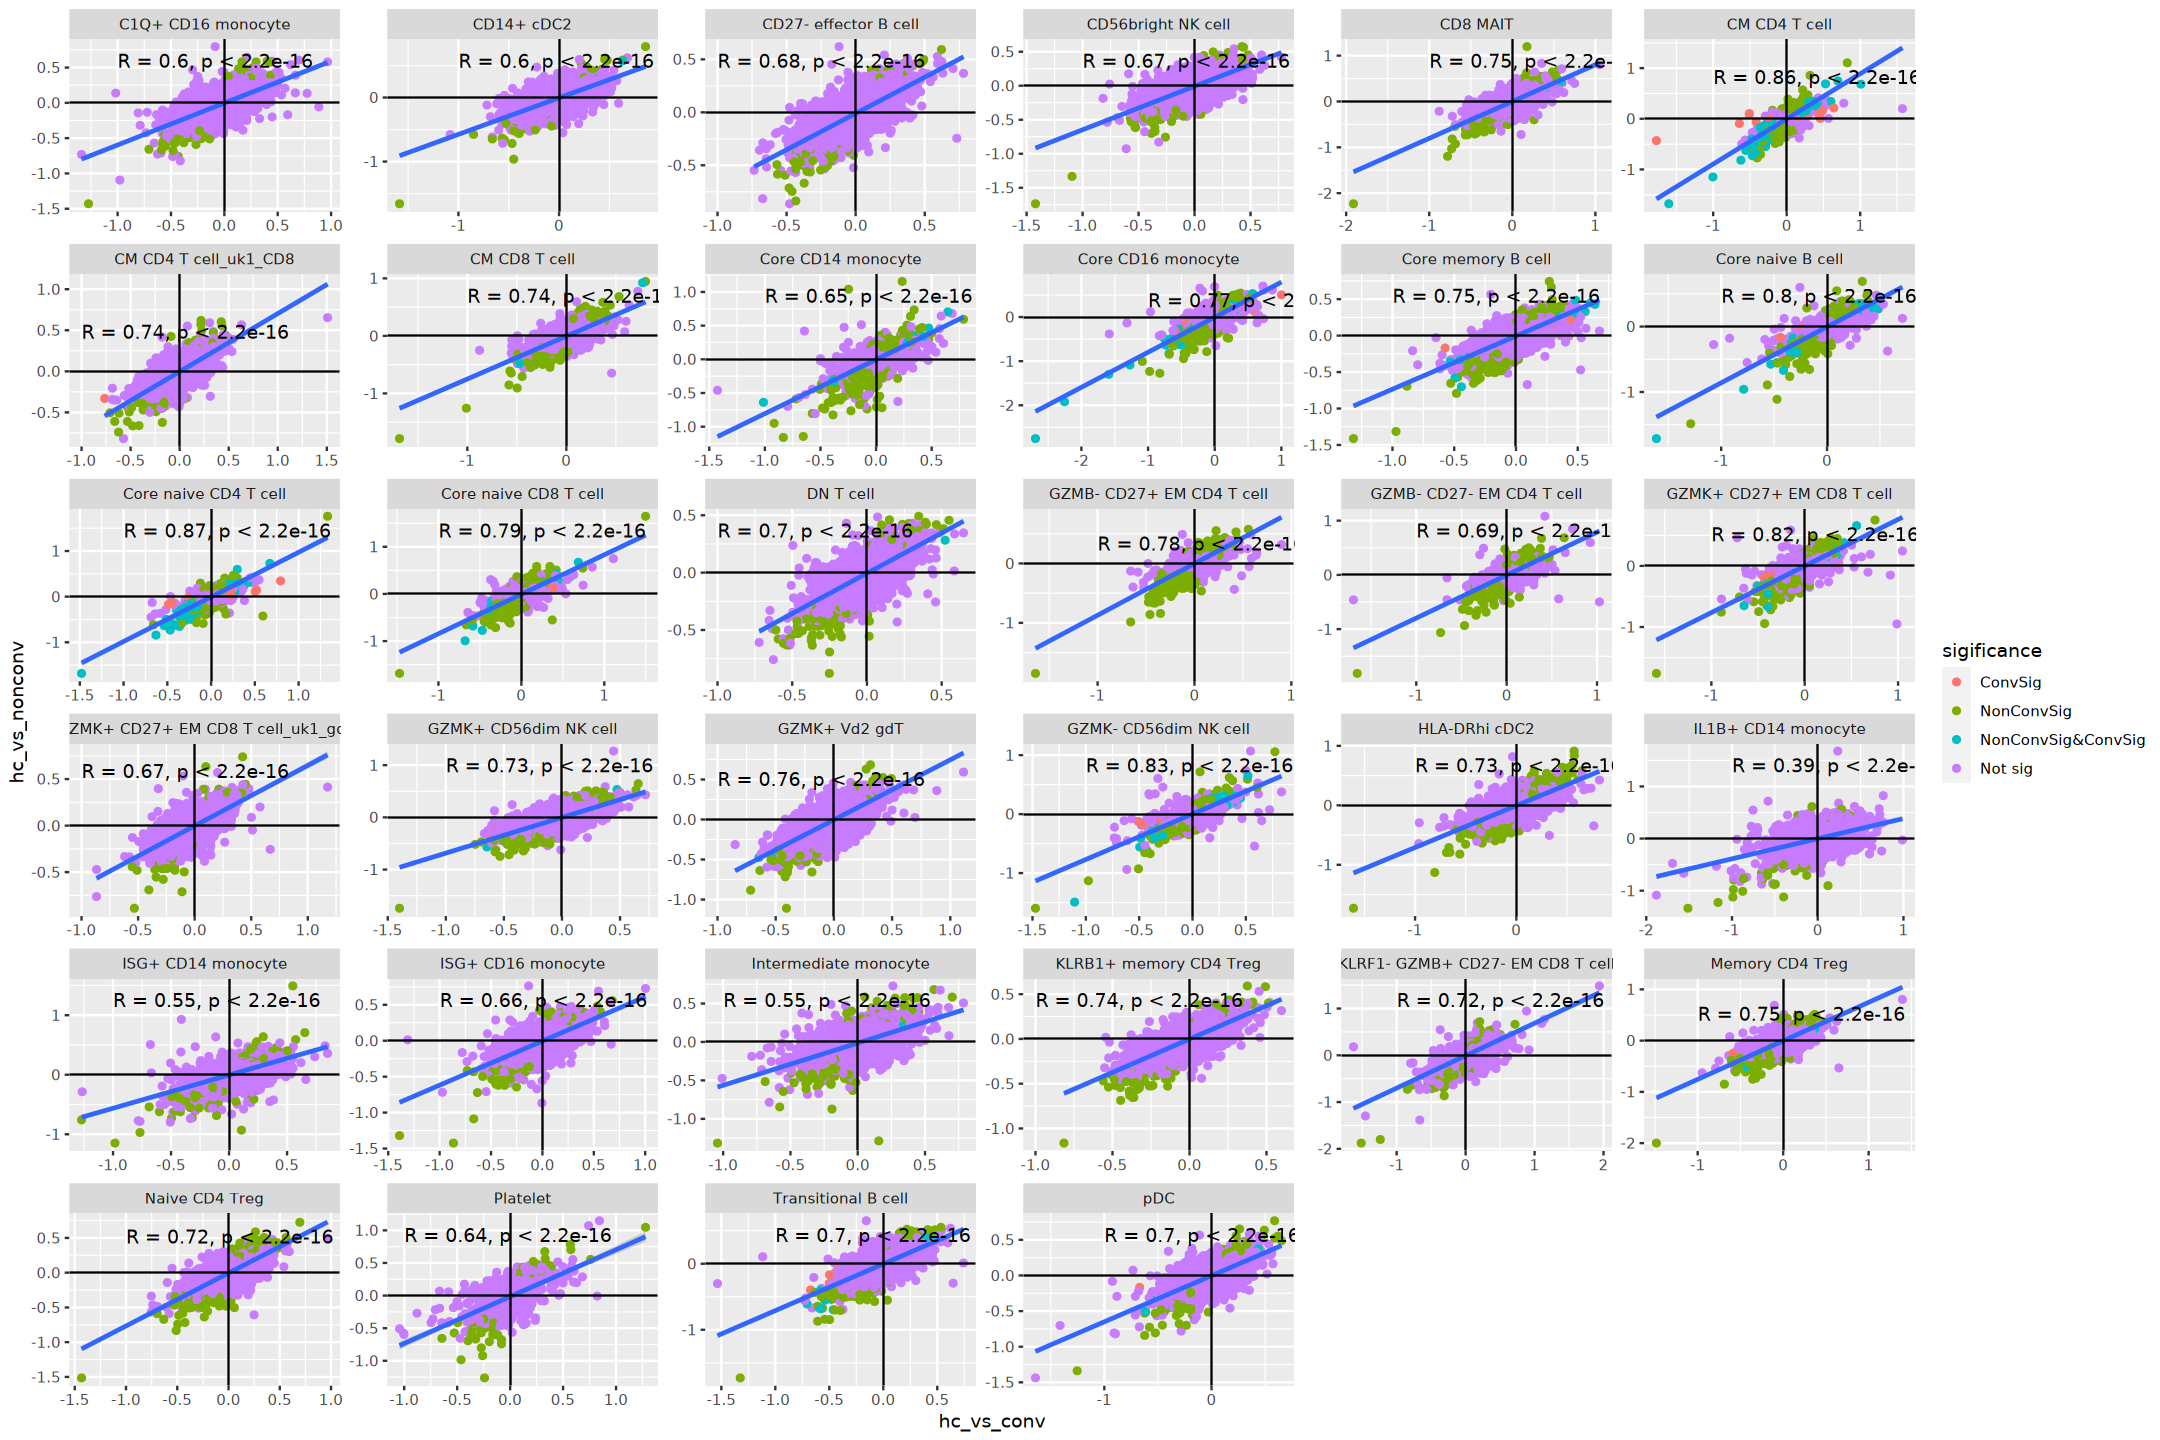

In [124]:
# only plot the cell type with >50 degs 
celltype_degs = aim1degs_counts%>%filter(n>50)%>%distinct(cell_type)%>%pull(cell_type)
# plot the correlation between the hc vs conv and hc vs non-conv
options(repr.plot.width = 18, repr.plot.height = 12)
p2 <- aim1_conv_nonconv_logfc %>% filter(cell_type%in%celltype_degs)%>%
    ggplot(aes(x=hc_vs_conv, y=hc_vs_nonconv
                          )) +
    geom_point(aes(color=sigificance)) +                                      
  stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+
    facet_wrap(vars(cell_type), scale='free')+ 
    ggpubr::stat_cor(method = "spearman", label.x = -1)
p2
ggsave(file.path(fig_path, paste0(proj_name,'deg_logfc_cor_plot_above50degs.png')),
       width=16, height=8)

## plot the reduced dimension

## only test in female

In [127]:
## B182 had dominant batch effect and need to adjust
female_aim1_pb <- lapply(subset_aim1_pb, function(pb){
    # only keep female
    pb = pb[ , colData(pb)$subject.biologicalSex == 'Female']
    return(pb)
})

In [128]:
female_aim1_pb[[10]]

class: SummarizedExperiment 
dim: 1060 25 
metadata(0):
assays(1): counts
rownames(1060): AAK1 ABCF1 ... ZNHIT1 ZRANB2
rowData names(0):
colnames: NULL
colData names(40): index batch_id ... scale_age scale_bmi

In [129]:
# run deseq to do deg analysis
formula = '~ scale_age + scale_bmi + batch_corr + status_converter'
aim1_deseq_female <- RunDeseq_list(female_aim1_pb, formula)

run Deseq2 for cell type Adaptive NK cell

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type Adaptive NK cell_uk1_T

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type C1Q+ CD16 monocyte

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type CD14+ cDC2

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell ty

In [130]:
# get deseq2 result
aim1deseq_female_res <- lapply(aim1_deseq_female, function(dds){
    celltype = dds$AIFI_L3_new%>%unique()
    res_nonconv_conv = results(dds, contrast=c("status_converter",  "converter", "non_converter")) %>% 
        as_tibble(rownames = 'gene') %>% mutate('contrast' = 'nonconv_vs_conv')
    res_hc_conv = results(dds, contrast=c("status_converter", "converter", "ALTRA_healthy")) %>% 
        as_tibble(rownames = 'gene') %>% mutate('contrast' = 'hc_vs_conv')
    res_hc_nonconv = results(dds, contrast=c("status_converter", "non_converter", "ALTRA_healthy")) %>% 
        as_tibble(rownames = 'gene') %>% mutate('contrast' = 'hc_vs_nonconv')
    res = res_nonconv_conv %>% bind_rows(res_hc_conv) %>% bind_rows(res_hc_nonconv)%>%
        mutate(cell_type = celltype) 
    return(res)
})%>%rbindlist()

In [135]:
aim1deseq_female_res%>%filter(padj<0.2&contrast =='nonconv_vs_conv')

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast,cell_type
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
TSC22D3,41.399855,1.1426471,0.28174114,4.055663,4.999233e-05,0.08858641,nonconv_vs_conv,CD4 MAIT
NOSIP,13.709505,-0.9120433,0.25818940,-3.532458,4.117151e-04,0.18156635,nonconv_vs_conv,CM CD4 T cell_uk2
HMGN1,283.499328,-0.6052224,0.13600190,-4.450103,8.582925e-06,0.06862907,nonconv_vs_conv,Core CD16 monocyte
ETFB,115.872290,0.3190923,0.07667526,4.161607,3.160159e-05,0.19371773,nonconv_vs_conv,GZMK- CD56dim NK cell
TLE3,13.370993,1.1620524,0.28658673,4.054802,5.017683e-05,0.15745488,nonconv_vs_conv,IL1B+ CD14 monocyte
HES4,9.618245,1.6129476,0.35955163,4.485997,7.257369e-06,0.04750674,nonconv_vs_conv,Intermediate monocyte
MRPL43,14.962758,-0.6739962,0.15894424,-4.240457,2.230652e-05,0.04871745,nonconv_vs_conv,ISG+ memory CD4 T cell
RPL35A,624.148306,0.2351530,0.05727445,4.105723,4.030529e-05,0.05022039,nonconv_vs_conv,Naive Vd1 gdT
IGKV1-39,17.902929,-5.0787245,1.23903358,-4.098940,4.150463e-05,0.14045166,nonconv_vs_conv,Plasma cell
